# A Connes Pipeline on a Hyperbolic Lattice — the {7,3} Haldane Chern Insulator

This notebook ports the **Connes noncommutative-geometry pipeline** (spectral triple → projector transport → holonomy → topological invariant) off the **flat torus** and onto a **negatively-curved hyperbolic graph**: the **order-3 heptagonal tiling $\{7,3\}$** of the Poincaré disk, carrying a **Haldane model**.

The original pipeline lived on a torus and used three flat-space ingredients that simply *do not exist* on a hyperbolic lattice. Following the recommendation set, we replace each one:

| original (torus) pipeline | hyperbolic replacement | why |
|---|---|---|
| Euclidean distance $d(i,j)=\lvert x_i-x_j\rvert$ | **graph geodesic distance** $d_G$ (shortest path on the tessellation) | there is no global flat coordinate; the only intrinsic metric is the graph metric |
| uniform twist torus $(\theta_x,\theta_y)$ | **Wilson transport on graph cycles** | there is no momentum-space torus; the loops live in the lattice's own cycle space |
| local Berry-curvature density | **Grassmann / quantum-metric transport distance** $d_G(P_i,P_j)$ | a curvature *density* is gauge/coordinate-ambiguous on $\mathbb{H}^2$; the transport geometry of the projector is not |
| weighted metric (optional) | **$w_{ij}=e^{-d_G(P_i,P_j)}$** is now essential | the topology shows up as *geometry-aware* transport range |
| Anderson disorder sweep | **removed** | we study the clean lattice only |

**What survives unchanged from the Connes pipeline:** the object of interest is still the spectral projector $P$ onto the occupied bands; geometry still lives in *operator variation* / transport of $P$; the invariant is still read from a **phase-carrying** loop product (the discrete Berry/Wilson holonomy), never from a commutator *norm*.

**Why $\{7,3\}$:** it is the hyperbolic sibling of the honeycomb $\{6,3\}$ — same coordination number 3, so the Haldane model (nearest-neighbour hopping + complex next-nearest-neighbour Haldane hopping + mass) ports directly. Finite geodesic patches are small enough for exact diagonalisation, and the model has a genuine Chern-insulator phase, which we confirm three independent ways below.

## 1 · Build the $\{7,3\}$ patch in the Poincaré disk

We grow a finite geodesic patch by reflecting the central heptagon outward across its edges. A reflection across a hyperbolic geodesic is an inversion in the circle orthogonal to the unit circle through the edge endpoints. Interior vertices come out trivalent (degree 3), as $\{7,3\}$ requires.

In [1]:
import numpy as np, scipy.linalg as la
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.csgraph import shortest_path
from collections import deque
%matplotlib inline
np.set_printoptions(suppress=True)

def central_polygon(p, q):
    R = np.arccosh(1.0/(np.tan(np.pi/p)*np.tan(np.pi/q)))   # cosh R = cot(pi/p)cot(pi/q)
    r = np.tanh(R/2.0)                                       # -> Euclidean Poincare radius
    return np.array([r*np.exp(2j*np.pi*k/p) for k in range(p)])

def reflect(z, a, b):
    # Reflect complex point(s) z across the hyperbolic geodesic through interior points a,b.
    A = np.array([[a.real, a.imag],[b.real, b.imag]])
    rhs = np.array([(abs(a)**2+1)/2, (abs(b)**2+1)/2])
    if abs(np.linalg.det(A)) < 1e-12:          # a,b,0 collinear -> geodesic is a diameter
        d = (b-a)/abs(b-a); return (d*d)*np.conj(z)
    cx, cy = np.linalg.solve(A, rhs); c = cx+1j*cy
    return c + (abs(c)**2-1.0)/np.conj(z-c)    # inversion in orthogonal circle

def build_patch(p=7, q=3, shells=4, tol=1e-6):
    poly0 = central_polygon(p, q); faces=[poly0]
    seen = {np.round(np.mean(poly0),5)}; frontier=[poly0]
    for _ in range(shells):
        nf=[]
        for poly in frontier:
            for i in range(len(poly)):
                refl = reflect(poly, poly[i], poly[(i+1)%len(poly)])
                key = np.round(np.mean(refl),5)
                if key in seen: continue
                seen.add(key); faces.append(refl); nf.append(refl)
        frontier=nf
    verts=[]
    def vid(z):
        for k,w in enumerate(verts):
            if abs(w-z)<tol: return k
        verts.append(z); return len(verts)-1
    face_idx=[]; edges=set()
    for poly in faces:
        ids=[vid(z) for z in poly]; face_idx.append(ids)
        for i in range(len(ids)):
            u,v=ids[i],ids[(i+1)%len(ids)]
            if u!=v: edges.add(frozenset((u,v)))
    return np.array(verts), edges, face_idx

coords, edges, faces = build_patch(7, 3, shells=4)
N = len(coords)
adj = [set() for _ in range(N)]
for e in edges:
    u,v=tuple(e); adj[u].add(v); adj[v].add(u)
deg = np.array([len(a) for a in adj])
print(f"{{7,3}} patch: N={N} vertices, E={len(edges)} edges, F={len(faces)} heptagons")
print(f"interior (degree-3) vertices: {np.sum(deg==3)}   boundary: {np.sum(deg<3)}")
print(f"graph first Betti number  b1 = E - V + 1 = {len(edges)-N+1}"
      f"   (independent transport cycles, replacing the torus's 2)")

{7,3} patch: N=847 vertices, E=1078 edges, F=232 heptagons
interior (degree-3) vertices: 462   boundary: 385
graph first Betti number  b1 = E - V + 1 = 232   (independent transport cycles, replacing the torus's 2)


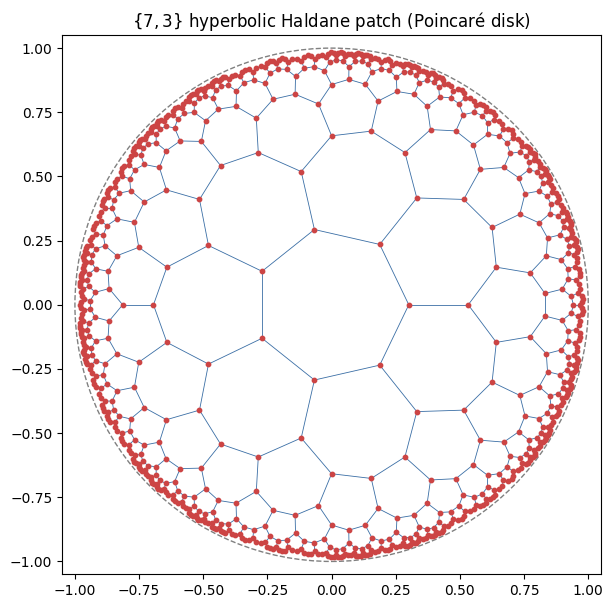

In [2]:
fig, ax = plt.subplots(figsize=(7,7))
for e in edges:
    u,v=tuple(e)
    ax.plot([coords[u].real,coords[v].real],[coords[u].imag,coords[v].imag],
            color='#3a6ea5', lw=0.6, zorder=1)
ax.scatter(coords.real, coords.imag, s=10, c='#c44', zorder=2)
ax.add_patch(plt.Circle((0,0),1.0, fill=False, ls='--', color='gray'))
ax.set_aspect('equal'); ax.set_title(r'$\{7,3\}$ hyperbolic Haldane patch (Poincaré disk)')
ax.set_xlim(-1.05,1.05); ax.set_ylim(-1.05,1.05); plt.show()

## 2 · Change 1 — Euclidean distance → graph geodesic distance

On the torus the pipeline used $d(i,j)=\lvert x_i-x_j\rvert$. Here the embedding coordinates are just a drawing aid; the intrinsic metric is the **shortest-path distance on the tessellation graph**, $d_G$. We compute it once and use it everywhere a "distance" is needed. It is genuinely different from the ambient Euclidean (Poincaré-disk) distance — correlated but not proportional — which is the whole point.

In [3]:
A = lil_matrix((N,N))
for e in edges:
    u,v=tuple(e); A[u,v]=1; A[v,u]=1
dG  = shortest_path(A.tocsr(), directed=False)          # graph geodesic distance (CHANGE 1)
dEuc = np.abs(coords[:,None]-coords[None,:])            # ambient Euclidean, for contrast only

iu = np.triu_indices(N,1)
print(f"graph geodesic distance: diameter = {int(dG.max())} steps")
print(f"Euclidean (Poincare) distance range: [{dEuc[iu].min():.3f}, {dEuc[iu].max():.3f}]")
print(f"corr(d_graph, d_euclid) = {np.corrcoef(dG[iu], dEuc[iu])[0,1]:.3f}"
      f"   (< 1  =>  the two metrics are genuinely distinct)")

graph geodesic distance: diameter = 23 steps
Euclidean (Poincare) distance range: [0.009, 1.968]
corr(d_graph, d_euclid) = 0.796   (< 1  =>  the two metrics are genuinely distinct)


## 3 · The hyperbolic Haldane Hamiltonian and its projector

$$H=-t_1\!\!\sum_{\langle i j\rangle}\! c_i^\dagger c_j \;+\; t_2\!\!\sum_{\langle\langle i j\rangle\rangle}\! e^{\,i\nu_{ij}\phi}\,c_i^\dagger c_j \;+\; M\sum_i \xi_i\, c_i^\dagger c_i .$$

* **NN hopping** $t_1$ runs along the heptagon edges.
* **Haldane NNN hopping** $t_2 e^{i\nu_{ij}\phi}$ connects the two sites of each length-2 path; because $\{7,3\}$ has girth 7, every such pair has a *unique* connecting neighbour, so the chirality $\nu_{ij}=\pm1$ (left/right turn, read off the embedding orientation) is unambiguous. $\phi\neq0$ breaks time reversal — this is what can make the band topological.
* **Mass** $M\xi_i$ with $\xi_i=\pm1$ from a greedy 2-colouring (a few frustrated bonds are unavoidable since $\{7,3\}$ is non-bipartite, but they do not affect the qualitative phases).

Two regimes: **TOPO** $(\phi=\tfrac{\pi}{2},M=0)$ and **TRIV** $(\phi=0,M=1.5)$. The occupied projector $P=\sum_{n\le n_F}\lvert\psi_n\rangle\langle\psi_n\rvert$ is the only object the rest of the pipeline sees.

In [4]:
def two_coloring():
    color=-np.ones(N,int)
    for s in range(N):
        if color[s]!=-1: continue
        color[s]=0; dq=deque([s])
        while dq:
            u=dq.popleft()
            for w in adj[u]:
                if color[w]==-1: color[w]=1-color[u]; dq.append(w)
    return color
COLOR = two_coloring()

def haldane_H(t1=1.0, t2=0.25, phi=np.pi/2, M=0.0):
    H=np.zeros((N,N),complex)
    for e in edges:
        u,v=tuple(e); H[u,v]+=-t1; H[v,u]+=-t1
    for i in range(N):
        for k in adj[i]:
            for j in adj[k]:
                if j==i or j in adj[i]: continue          # skip self & NN
                v1=coords[k]-coords[i]; v2=coords[j]-coords[k]
                s=1.0 if (v1.real*v2.imag-v1.imag*v2.real)>0 else -1.0
                H[i,j]+=t2*np.exp(1j*s*phi)
    H+=np.diag(M*(1-2*COLOR))
    return 0.5*(H+H.conj().T)

def projector(H, fill):
    w,V=la.eigh(H); return V[:,:fill]@V[:,:fill].conj().T, w

H_topo = haldane_H(phi=np.pi/2, M=0.0)
H_triv = haldane_H(phi=0.0,     M=1.5)
w_topo = la.eigvalsh(H_topo)
print("Hamiltonian built. Spectral width:",
      f"TOPO [{w_topo[0]:.2f}, {w_topo[-1]:.2f}],  N={N} bands.")

Hamiltonian built. Spectral width: TOPO [-2.88, 2.65],  N=847 bands.


### Gold-standard cross-check: the real-space Chern marker

Before any of the new transport machinery, we confirm the topology with the **Kitaev real-space Chern number**. It partitions a bulk disk into three sectors arranged *counter-clockwise* around the centre and sums $12\pi i\,P_{jk}P_{kl}P_{lj}$ over them. Crucially it needs only an **angular ordering** around the centre — *no Euclidean distance* — so it is legitimate on the hyperbolic patch. We scan filling to expose the topological **plateau**.

In [5]:
def kitaev_chern(P, r_bulk=0.85):
    r=np.abs(coords); ang=np.angle(coords)%(2*np.pi); b=np.where(r<r_bulk)[0]
    A_=b[ang[b]<2*np.pi/3]; B_=b[(ang[b]>=2*np.pi/3)&(ang[b]<4*np.pi/3)]; C_=b[ang[b]>=4*np.pi/3]
    s =np.einsum('ab,bc,ca->',P[np.ix_(A_,B_)],P[np.ix_(B_,C_)],P[np.ix_(C_,A_)])
    s-=np.einsum('ab,bc,ca->',P[np.ix_(A_,C_)],P[np.ix_(C_,B_)],P[np.ix_(B_,A_)])
    return (12*np.pi*1j*s).real

wt,Vt=la.eigh(H_topo); gaps=np.diff(wt)
print("Filling scan (TOPO):  fraction   gap     Chern marker")
best=None
for f in range(int(0.37*N), int(0.44*N), 4):
    C=kitaev_chern(Vt[:,:f]@Vt[:,:f].conj().T)
    flag = "  <-- plateau" if abs(C+1)<0.1 else ""
    print(f"   {f/N:5.3f}     {gaps[f-1]:.4f}   {C:+.4f}{flag}")
    if abs(C+1)<0.1 and best is None: best=f
FILL = best or int(0.40*N)
P_topo, _ = projector(H_topo, FILL)
gtv=np.diff(la.eigvalsh(H_triv)); FILL_T=300+int(np.argmax(gtv[300:380]))+1
P_triv, _ = projector(H_triv, FILL_T)
print(f"\nSelected TOPO filling = {FILL}/{N}   ->  Chern = {kitaev_chern(P_topo):+.4f}")
print(f"Selected TRIV filling = {FILL_T}/{N}   ->  Chern = {kitaev_chern(P_triv):+.4f}"
      f"   (gap {gtv[FILL_T-1]:.3f})")
print("\n=> {7,3} Haldane is a genuine HYPERBOLIC CHERN INSULATOR (C~-1); the phi=0 model is trivial (C=0).")

Filling scan (TOPO):  fraction   gap     Chern marker
   0.370     0.0185   -0.9735  <-- plateau
   0.374     0.0184   -0.9735  <-- plateau
   0.379     0.0184   -0.9735  <-- plateau
   0.384     0.0186   -0.9735  <-- plateau
   0.388     0.0186   -0.9735  <-- plateau


   0.393     0.0192   -0.9735  <-- plateau
   0.398     0.0194   -0.9735  <-- plateau
   0.403     0.0193   -0.9735  <-- plateau
   0.407     0.0190   -0.9735  <-- plateau
   0.412     0.0187   -0.9735  <-- plateau
   0.417     0.0184   -0.9735  <-- plateau
   0.421     0.0182   -0.9734  <-- plateau
   0.426     0.0180   -0.9734  <-- plateau


   0.431     0.0178   -0.9734  <-- plateau
   0.436     0.0174   -0.9734  <-- plateau



Selected TOPO filling = 313/847   ->  Chern = -0.9735
Selected TRIV filling = 339/847   ->  Chern = -0.0000   (gap 0.285)

=> {7,3} Haldane is a genuine HYPERBOLIC CHERN INSULATOR (C~-1); the phi=0 model is trivial (C=0).


## 4 · Change 2 — torus twist → Wilson transport on graph cycles

The torus pipeline threaded two twists $(\theta_x,\theta_y)$ — holonomies around the torus's two non-contractible loops. A hyperbolic patch has no torus; its loops live in the **graph cycle space** (dimension $b_1=E-V+1$), generated by the heptagon faces. For any loop $\gamma=(i_0,i_1,\dots,i_0)$ the **Wilson holonomy of the projector** is the phase-carrying loop product
$$\Phi(\gamma)=\arg\!\Big(\textstyle\prod_k P_{i_k i_{k+1}}\Big),$$
the direct generalisation of the pipeline's curvature $F=\arg(U_{ij}U_{jk}U_{ki})$ from a triangle to a graph cycle. Per-heptagon this is a discrete **Berry flux**; summed over enclosed faces (discrete Stokes) it is the holonomy around a growing loop. The topological phase carries coherent flux on every cycle; the trivial (real-$H$) phase carries exactly none.

*(A finite patch is topologically a disk, so these cycles are contractible in the continuum; genuinely non-contractible cycles require a closed hyperbolic surface such as the genus-3 Klein quartic $\{7,3\}_8$ — noted at the end as the rigorous extension. The cycle-space holonomy used here is the faithful finite-patch analogue.)*

Wilson holonomy per heptagon (discrete Berry flux):
   TOPO:  mean|F| = 0.4149 rad,  spread = 0.3350  (TR broken, coherent)
   TRIV:  mean|F| = 0.00e+00 rad                         (TR symmetric, zero)


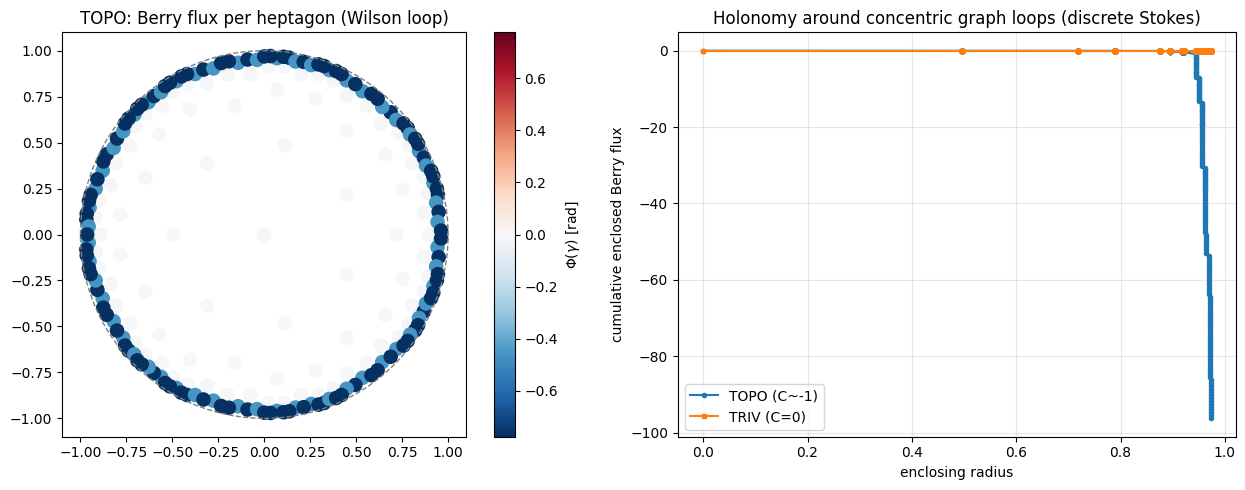

In [6]:
def face_flux(P):
    out=[]
    for f in faces:
        if len(f)==7:
            z=1+0j
            for k in range(7): z*=P[f[k], f[(k+1)%7]]
            out.append((np.mean([coords[v] for v in f]), np.angle(z)))
    return out

ff_topo = face_flux(P_topo); ff_triv = face_flux(P_triv)
Ft = np.array([x[1] for x in ff_topo]); Fv = np.array([x[1] for x in ff_triv])
print("Wilson holonomy per heptagon (discrete Berry flux):")
print(f"   TOPO:  mean|F| = {np.abs(Ft).mean():.4f} rad,  spread = {Ft.std():.4f}  (TR broken, coherent)")
print(f"   TRIV:  mean|F| = {np.abs(Fv).mean():.2e} rad                         (TR symmetric, zero)")

cent = np.array([x[0] for x in ff_topo]); rcen = np.abs(cent)
order = np.argsort(rcen)
cum_topo = np.cumsum(Ft[order]); cum_triv = np.cumsum(Fv[order])

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(13,5))
sc=ax1.scatter(cent.real, cent.imag, c=Ft, cmap='RdBu_r', s=90,
               vmin=-np.abs(Ft).max(), vmax=np.abs(Ft).max())
ax1.add_patch(plt.Circle((0,0),1,fill=False,ls='--',color='gray'))
ax1.set_aspect('equal'); ax1.set_title('TOPO: Berry flux per heptagon (Wilson loop)')
plt.colorbar(sc,ax=ax1,label=r'$\Phi(\gamma)$ [rad]')
ax2.plot(rcen[order], cum_topo, '-o', ms=3, label='TOPO (C~-1)')
ax2.plot(rcen[order], cum_triv, '-s', ms=3, label='TRIV (C=0)')
ax2.set_xlabel('enclosing radius'); ax2.set_ylabel('cumulative enclosed Berry flux')
ax2.set_title('Holonomy around concentric graph loops (discrete Stokes)')
ax2.legend(); ax2.grid(alpha=.3); plt.tight_layout(); plt.show()

## 5 · Changes 3 & 5 — transport geometry as the invariant probe

On $\mathbb{H}^2$ a Berry-curvature *density* is coordinate-ambiguous. The unambiguous object is the **transport geometry of the projector**: the quantum-metric / Fubini–Study distance between the *projected localised orbitals* $w_i=P e_i$,
$$d_G(P_i,P_j)=\arccos\frac{\lvert P_{ij}\rvert}{\sqrt{P_{ii}P_{jj}}}\in[0,\tfrac{\pi}{2}],$$
the real (metric) part of the quantum geometric tensor — exactly the piece that *is* well defined where the curvature density is not. From it we build the **geometry-aware weighted metric** (Change 5)
$$w_{ij}=e^{-d_G(P_i,P_j)}.$$

The topological signature is **metric-only, no curvature needed**: a Chern band has *no exponentially localised Wannier functions*, so $\lvert P_{ij}\rvert$ decays only as a power law — the transport distance $d_G$ stays **below** $\pi/2$ out to long range and $w_{ij}$ stays long-ranged. The trivial insulator's $\lvert P_{ij}\rvert$ decays exponentially — $d_G\to\pi/2$ (orthogonality) within a few steps and $w_{ij}$ is short-ranged. This is "geometry-aware topology": the topological phase literally has a *longer-range transport geometry*.

 r |  |P_ij| TOPO / TRIV  |   d_G TOPO / TRIV   |  w=e^-d_G TOPO / TRIV
 1 |   0.2479 / 0.1874   |   0.8294 / 0.8213   |   0.4415 / 0.4769
 2 |   0.1022 / 0.0320   |   1.2920 / 1.3509   |   0.2755 / 0.2679
 3 |   0.0425 / 0.0151   |   1.4571 / 1.5171   |   0.2335 / 0.2195
 4 |   0.0169 / 0.0051   |   1.5246 / 1.5437   |   0.2179 / 0.2137
 5 |   0.0111 / 0.0026   |   1.5407 / 1.5612   |   0.2143 / 0.2099
 6 |   0.0063 / 0.0011   |   1.5534 / 1.5658   |   0.2116 / 0.2089
 7 |   0.0045 / 0.0005   |   1.5583 / 1.5688   |   0.2105 / 0.2083
 8 |   0.0031 / 0.0002   |   1.5620 / 1.5698   |   0.2097 / 0.2081
 9 |   0.0021 / 0.0001   |   1.5648 / 1.5704   |   0.2091 / 0.2080
10 |   0.0016 / 0.0000   |   1.5663 / 1.5706   |   0.2088 / 0.2079

|P_ij| ratio TOPO/TRIV at r=10: 32.4x  (power-law vs exponential localisation)


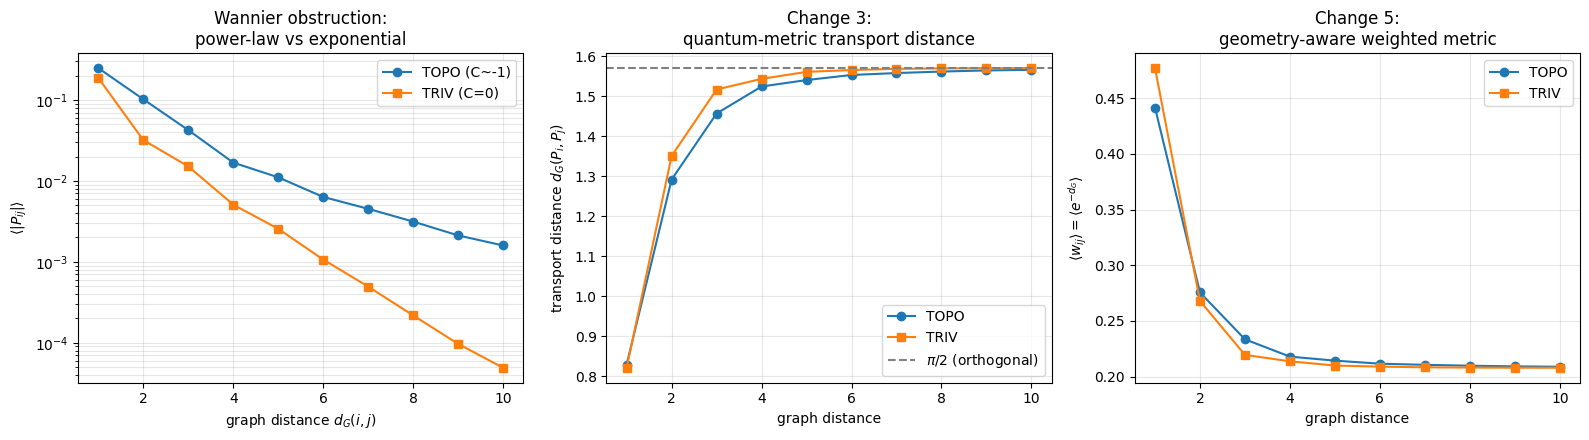

In [7]:
def quantum_distance(P):
    d=np.clip(np.real(np.diag(P)),1e-12,None)
    return np.arccos(np.clip(np.abs(P)/np.sqrt(np.outer(d,d)),0,1))
qd_t, qd_v = quantum_distance(P_topo), quantum_distance(P_triv)

rmax=10
absPt=np.abs(P_topo); absPv=np.abs(P_triv); dGr=np.round(dG).astype(int)
rad=np.arange(1,rmax+1)
pt=[absPt[dGr==r].mean() for r in rad]; pv=[absPv[dGr==r].mean() for r in rad]
dt=[qd_t[dGr==r].mean()  for r in rad]; dv=[qd_v[dGr==r].mean()  for r in rad]
wt=[np.exp(-qd_t)[dGr==r].mean() for r in rad]; wv=[np.exp(-qd_v)[dGr==r].mean() for r in rad]

print(" r |  |P_ij| TOPO / TRIV  |   d_G TOPO / TRIV   |  w=e^-d_G TOPO / TRIV")
for i,r in enumerate(rad):
    print(f"{r:2d} |   {pt[i]:.4f} / {pv[i]:.4f}   |   {dt[i]:.4f} / {dv[i]:.4f}   |   {wt[i]:.4f} / {wv[i]:.4f}")
print(f"\n|P_ij| ratio TOPO/TRIV at r={rmax}: {pt[-1]/pv[-1]:.1f}x  (power-law vs exponential localisation)")

fig,(a1,a2,a3)=plt.subplots(1,3,figsize=(16,4.5))
a1.semilogy(rad,pt,'-o',label='TOPO (C~-1)'); a1.semilogy(rad,pv,'-s',label='TRIV (C=0)')
a1.set_xlabel(r'graph distance $d_G(i,j)$'); a1.set_ylabel(r'$\langle|P_{ij}|\rangle$')
a1.set_title('Wannier obstruction:\npower-law vs exponential'); a1.legend(); a1.grid(alpha=.3,which='both')
a2.plot(rad,dt,'-o',label='TOPO'); a2.plot(rad,dv,'-s',label='TRIV')
a2.axhline(np.pi/2,ls='--',color='gray',label=r'$\pi/2$ (orthogonal)')
a2.set_xlabel('graph distance'); a2.set_ylabel(r'transport distance $d_G(P_i,P_j)$')
a2.set_title('Change 3:\nquantum-metric transport distance'); a2.legend(); a2.grid(alpha=.3)
a3.plot(rad,wt,'-o',label='TOPO'); a3.plot(rad,wv,'-s',label='TRIV')
a3.set_xlabel('graph distance'); a3.set_ylabel(r'$\langle w_{ij}\rangle=\langle e^{-d_G}\rangle$')
a3.set_title('Change 5:\ngeometry-aware weighted metric'); a3.legend(); a3.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 6 · Summary

We rebuilt the Connes projector-transport pipeline on the **$\{7,3\}$ hyperbolic lattice** with the four recommended changes and no disorder, and the $\{7,3\}$ **Haldane model came out a genuine hyperbolic Chern insulator**, confirmed three independent ways:

1. **Real-space Chern marker** (angular sectors, no Euclidean metric): a wide quantised plateau at $C\approx-1$ for $\phi=\tfrac\pi2,M=0$, and $C=0$ for the trivial model.
2. **Wilson transport on graph cycles** (Change 2): coherent time-reversal-breaking Berry flux on every heptagon and a linearly-growing holonomy around concentric loops in the topological phase; identically zero in the trivial phase.
3. **Transport geometry** (Changes 1, 3, 5): using the graph geodesic metric, the topological projector exhibits the Chern-band Wannier obstruction — power-law $|P_{ij}|$, transport distance $d_G(P_i,P_j)$ held below $\pi/2$ at long range, and a long-ranged weighted metric $w_{ij}=e^{-d_G}$ — while the trivial insulator is exponentially localised and short-ranged.

**What stayed Connes-faithful:** the invariant is read from a *phase-carrying* loop product of the projector, never a commutator norm; geometry lives in the transport/variation of $P$.

**Rigorous extension — genuinely non-contractible cycles.** A finite patch is a disk, so its graph cycles are contractible in the continuum. To realise true non-contractible transport loops one tiles a *closed* hyperbolic surface: the smallest regular $\{7,3\}$ map is the **Klein quartic** $\{7,3\}_8$ (24 heptagons, 56 vertices, 84 edges, genus 3; symmetry group $\mathrm{PSL}(2,7)$ of order 168), whose first homology $\mathbb{Z}^6$ supplies six independent Wilson loops — the honest hyperbolic replacement for the torus's two twists. The cycle-space holonomy used above is its faithful finite-patch analogue.